# Sequence 000007 – Data Exploration

**Goal:** Verify five things before writing any pipeline code:
1. `object_detection.json` — pedestrian fields and coordinate frame
2. Timestamp matching — nearest LiDAR file to keyframe (gap ≤55ms)
3. LiDAR point cloud — load `.npy`, confirm points land inside pedestrian 3D box
4. `ego_road.json` — check whether polygon coordinate frame matches `location_3d`
5. Bird's-eye plot — LiDAR scan + pedestrian centroid (+ road polygon if in ego frame)

In [1]:
import json
import datetime
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.spatial.transform import Rotation

SEQ_ID   = "000007"
BASE_DIR = Path("/home/user20/projects/zod-ped/data/raw/sequences") / SEQ_ID

# Convenience loader
def load_json(rel):
    with open(BASE_DIR / rel) as f:
        return json.load(f)

---
## Step 1 – `object_detection.json`: pedestrian fields & coordinate frame

In [2]:
detections = load_json("annotations/object_detection.json")
pedestrians = [d for d in detections if d["properties"]["class"] == "Pedestrian"]
print(f"Total annotations : {len(detections)}")
print(f"Pedestrians       : {len(pedestrians)}")

Total annotations : 31
Pedestrians       : 10


In [3]:
# Inspect the first pedestrian entry
ped0 = pedestrians[0]
props = ped0["properties"]

print("=== 2D image bbox (MultiPoint, pixel coordinates) ===")
print(ped0["geometry"])

print("\n=== 3D annotation fields ===")
fields_3d = [
    "orientation_3d_qw", "orientation_3d_qx", "orientation_3d_qy", "orientation_3d_qz",
    "size_3d_length", "size_3d_width", "size_3d_height",
]
for f in fields_3d:
    print(f"  {f}: {props[f]}")

cx, cy, cz = props["location_3d"]["coordinates"]
print(f"\n  location_3d (ego/sensor frame, metres): x={cx:.3f}  y={cy:.3f}  z={cz:.3f}")
print(f"  → {cx:.1f}m ahead, {cy:.1f}m left, {cz:.1f}m up from ego")
print(f"\n  size_3d: L={props['size_3d_length']}m  W={props['size_3d_width']}m  H={props['size_3d_height']}m")

=== 2D image bbox (MultiPoint, pixel coordinates) ===
{'type': 'MultiPoint', 'coordinates': [[400.1336505517576, 1107.145779593832], [423.5255432128906, 1169.8050537109375], [399.6921081542969, 1224.6220703125], [380.0295104980469, 1166.825927734375]]}

=== 3D annotation fields ===
  orientation_3d_qw: 0.9999247630335417
  orientation_3d_qx: 0
  orientation_3d_qy: 0
  orientation_3d_qz: 0.012266550954336835
  size_3d_length: 0.511
  size_3d_width: 0.51
  size_3d_height: 1.313

  location_3d (ego/sensor frame, metres): x=-18.796  y=17.119  z=-1.492
  → -18.8m ahead, 17.1m left, -1.5m up from ego

  size_3d: L=0.511m  W=0.51m  H=1.313m


In [4]:
# Some pedestrians are 2D-only (no location_3d) — keep only those with 3D annotations
peds_3d = [p for p in pedestrians if "location_3d" in p["properties"]]
print(f"Pedestrians total : {len(pedestrians)}")
print(f"With 3D box       : {len(peds_3d)}")
print(f"2D-only (skipped) : {len(pedestrians) - len(peds_3d)}")

ped_centroids = np.array([
    p["properties"]["location_3d"]["coordinates"]
    for p in peds_3d
])  # shape (N, 3): [x, y, z] in ego frame

print("\nAll 3D pedestrian centroids (ego frame, metres)")
print("   x (fwd)   y (left)   z (up)")
for i, (x, y, z) in enumerate(ped_centroids):
    print(f"  [{i}]  {x:7.2f}   {y:8.2f}   {z:6.2f}")

Pedestrians total : 10
With 3D box       : 9
2D-only (skipped) : 1

All 3D pedestrian centroids (ego frame, metres)
   x (fwd)   y (left)   z (up)
  [0]   -18.80      17.12    -1.49
  [1]     3.53       9.48    -0.98
  [2]     3.86       7.11    -0.87
  [3]    10.22      52.51    -0.10
  [4]     6.91      34.68    -0.47
  [5]   -23.19      46.15    -1.40
  [6]   -22.42      46.46    -1.40
  [7]   -18.57      14.55    -1.46
  [8]   -17.76      18.79    -1.34


**Coordinate frame confirmed:** `location_3d` is in the **ego/sensor frame** — x forward, y left, z up, centred at the ego vehicle at keyframe time. Values are in metres.

---
## Step 2 – Timestamp matching: find nearest LiDAR scan to keyframe (≤55ms)

In [5]:
info = load_json("info.json")
keyframe_str = info["keyframe_time"]  # e.g. '2022-02-23T15:24:35.629349Z'
keyframe_dt  = datetime.datetime.fromisoformat(keyframe_str.replace("Z", "+00:00"))
keyframe_ts  = keyframe_dt.timestamp()

print(f"Sequence start : {info['start_time']}")
print(f"Keyframe time  : {keyframe_str}  (unix {keyframe_ts:.6f})")
print(f"Sequence end   : {info['end_time']}")

Sequence start : 2022-02-23T15:24:25.666758Z
Keyframe time  : 2022-02-23T15:24:35.629349Z  (unix 1645629875.629349)
Sequence end   : 2022-02-23T15:24:45.777853Z


In [6]:
LIDAR_DIR = BASE_DIR / "lidar_velodyne"

def lidar_ts(filename: str) -> float:
    """Parse UTC timestamp from LiDAR filename stem."""
    stem = filename.replace(".npy", "")
    ts_part = stem.split("_", 2)[2]  # '2022-02-23T15:24:35.666774Z'
    return datetime.datetime.fromisoformat(ts_part.replace("Z", "+00:00")).timestamp()

lidar_files = sorted(LIDAR_DIR.glob("*.npy"))
print(f"LiDAR scans available: {len(lidar_files)}")

diffs = [(abs(lidar_ts(f.name) - keyframe_ts), f) for f in lidar_files]
diffs.sort()

best_gap_s, best_file = diffs[0]
best_gap_ms = best_gap_s * 1000

print(f"\nTop-5 nearest LiDAR scans to keyframe:")
for gap_s, fn in diffs[:5]:
    flag = "  ← BEST" if fn == best_file else ""
    print(f"  gap={gap_s*1000:6.1f}ms  {fn.name}{flag}")

assert best_gap_ms <= 55, f"Nearest LiDAR scan is {best_gap_ms:.1f}ms away — exceeds 55ms limit!"
print(f"\nNearest scan ({best_gap_ms:.1f}ms) is within the 55ms limit.")
LIDAR_FILE = best_file

LiDAR scans available: 182

Top-5 nearest LiDAR scans to keyframe:
  gap=  37.4ms  000007_sierra_2022-02-23T15:24:35.666774Z.npy  ← BEST
  gap=  73.7ms  000007_sierra_2022-02-23T15:24:35.555664Z.npy
  gap= 148.6ms  000007_sierra_2022-02-23T15:24:35.777924Z.npy
  gap= 184.8ms  000007_sierra_2022-02-23T15:24:35.444517Z.npy
  gap= 259.7ms  000007_sierra_2022-02-23T15:24:35.889063Z.npy

Nearest scan (37.4ms) is within the 55ms limit.


---
## Step 3 – LiDAR point cloud: load and verify points land in pedestrian 3D box

In [7]:
cloud = np.load(LIDAR_FILE)
print(f"File  : {LIDAR_FILE.name}")
print(f"Shape : {cloud.shape}")
print(f"dtype : {cloud.dtype}")
print(f"\nColumn ranges:")
for name in cloud.dtype.names:
    col = cloud[name].astype(float)
    print(f"  {name:12s}: min={col.min():10.3f}  max={col.max():10.3f}")

File  : 000007_sierra_2022-02-23T15:24:35.666774Z.npy
Shape : (276620,)
dtype : [('x', '<f4'), ('y', '<f4'), ('z', '<f4'), ('timestamp', '<i8'), ('intensity', 'u1'), ('diode_index', 'u1')]

Column ranges:
  x           : min=   -81.612  max=    89.496
  y           : min=  -232.679  max=   213.780
  z           : min=    -6.332  max=    22.167
  timestamp   : min=-57534.000  max= 57535.000
  intensity   : min=     0.000  max=   255.000
  diode_index : min=     1.000  max=   160.000


In [8]:
pts = np.stack([cloud["x"], cloud["y"], cloud["z"]], axis=1)  # (N, 3)
print(f"Point cloud: {len(pts):,} points in ego/sensor frame")

Point cloud: 276,620 points in ego/sensor frame


In [9]:
def points_in_oriented_box(pts_xyz, cx, cy, cz, qw, qx, qy, qz, length, width, height):
    """
    Return mask of points inside an oriented 3D box.
    Box convention (ZOD): centre (cx,cy,cz), quaternion rotation, half-sizes l/2 w/2 h/2.
    """
    centre = np.array([cx, cy, cz])
    rot = Rotation.from_quat([qx, qy, qz, qw])  # scipy uses [x,y,z,w]
    local = rot.inv().apply(pts_xyz - centre)
    inside = (
        (np.abs(local[:, 0]) <= length / 2) &
        (np.abs(local[:, 1]) <= width  / 2) &
        (np.abs(local[:, 2]) <= height / 2)
    )
    return inside


print("LiDAR points inside each pedestrian 3D box (peds_3d only):")
print(f"  {'#':>2}  {'n_pts':>6}  {'centroid (x,y,z)':>26}  {'L x W x H':>18}")

ped_box_results = []
for i, ped in enumerate(peds_3d):
    p = ped["properties"]
    cx, cy, cz = p["location_3d"]["coordinates"]
    mask = points_in_oriented_box(
        pts,
        cx, cy, cz,
        p["orientation_3d_qw"], p["orientation_3d_qx"],
        p["orientation_3d_qy"], p["orientation_3d_qz"],
        p["size_3d_length"], p["size_3d_width"], p["size_3d_height"],
    )
    n = mask.sum()
    ped_box_results.append((i, n, mask))
    centroid_str = f"({cx:6.2f},{cy:6.2f},{cz:6.2f})"
    size_str = f"{p['size_3d_length']:.2f}x{p['size_3d_width']:.2f}x{p['size_3d_height']:.2f}"
    print(f"  {i:>2}  {n:>6}  {centroid_str:>26}  {size_str:>18}")

LiDAR points inside each pedestrian 3D box (peds_3d only):
   #   n_pts            centroid (x,y,z)           L x W x H
   0      51      (-18.80, 17.12, -1.49)      0.51x0.51x1.31
   1     973      (  3.53,  9.48, -0.98)      0.45x0.89x1.63
   2    1092      (  3.86,  7.11, -0.87)      0.47x0.73x1.86
   3       8      ( 10.22, 52.51, -0.10)      0.54x0.57x1.47
   4     113      (  6.91, 34.68, -0.47)      0.79x0.74x1.77
   5      24      (-23.19, 46.15, -1.40)      0.69x0.73x1.80
   6      19      (-22.42, 46.46, -1.40)      0.69x0.73x1.80
   7     164      (-18.57, 14.55, -1.46)      0.59x0.65x1.38
   8      29      (-17.76, 18.79, -1.34)      0.51x0.51x1.61


In [10]:
# Sanity-check: if zero points → likely coordinate frame mismatch
empty_boxes = [i for i, n, _ in ped_box_results if n == 0]
if empty_boxes:
    print(f"WARNING: {len(empty_boxes)} box(es) have 0 LiDAR points: {empty_boxes}")
    print("→ Check calibration.json for a LiDAR-to-annotation transform.")
else:
    print(f"All {len(ped_box_results)} boxes contain LiDAR points — coordinate frames match.")

All 9 boxes contain LiDAR points — coordinate frames match.


---
## Step 4 – `ego_road.json`: coordinate frame check

In [11]:
ego_road = load_json("annotations/ego_road.json")
print(f"Type        : {type(ego_road)}")
print(f"N polygons  : {len(ego_road)}")

# Grab the first polygon's coordinates
poly0 = ego_road[0]
print(f"Geometry type: {poly0['geometry']['type']}")
coords = np.array(poly0["geometry"]["coordinates"][0])  # outer ring
print(f"N vertices  : {len(coords)}")
print(f"x range     : {coords[:,0].min():.1f} – {coords[:,0].max():.1f}")
print(f"y range     : {coords[:,1].min():.1f} – {coords[:,1].max():.1f}")

Type        : <class 'list'>
N polygons  : 2
Geometry type: Polygon
N vertices  : 13
x range     : 208.1 – 874.1
y range     : 1586.7 – 1737.8


In [12]:
# Determine coordinate frame
calib = load_json("calibration.json")
img_w, img_h = calib["FC"]["image_dimensions"]   # [3848, 2168]

x_range = (coords[:,0].min(), coords[:,0].max())
y_range = (coords[:,1].min(), coords[:,1].max())

in_image_space = (0 <= x_range[0] and x_range[1] <= img_w and
                  0 <= y_range[0] and y_range[1] <= img_h)
in_ego_space   = (np.abs(coords).max() < 300)  # ego coords typically < 300m

print(f"Image dimensions (W x H) : {img_w} x {img_h}")
print(f"ego_road x range         : {x_range[0]:.1f} – {x_range[1]:.1f}")
print(f"ego_road y range         : {y_range[0]:.1f} – {y_range[1]:.1f}")
print()
if in_image_space:
    print("CONCLUSION: ego_road is in IMAGE (pixel) coordinates — NOT the ego/sensor frame.")
    print("→ Bird's-eye plot will show LiDAR + ped centroids only; road polygon needs projection.")
else:
    print("CONCLUSION: ego_road coordinates appear to be in 3D/ego space (values outside image bounds).")

Image dimensions (W x H) : 3848 x 2168
ego_road x range         : 208.1 – 874.1
ego_road y range         : 1586.7 – 1737.8

CONCLUSION: ego_road is in IMAGE (pixel) coordinates — NOT the ego/sensor frame.
→ Bird's-eye plot will show LiDAR + ped centroids only; road polygon needs projection.


---
## Step 5 – Bird's-eye view: LiDAR scan + pedestrian centroids

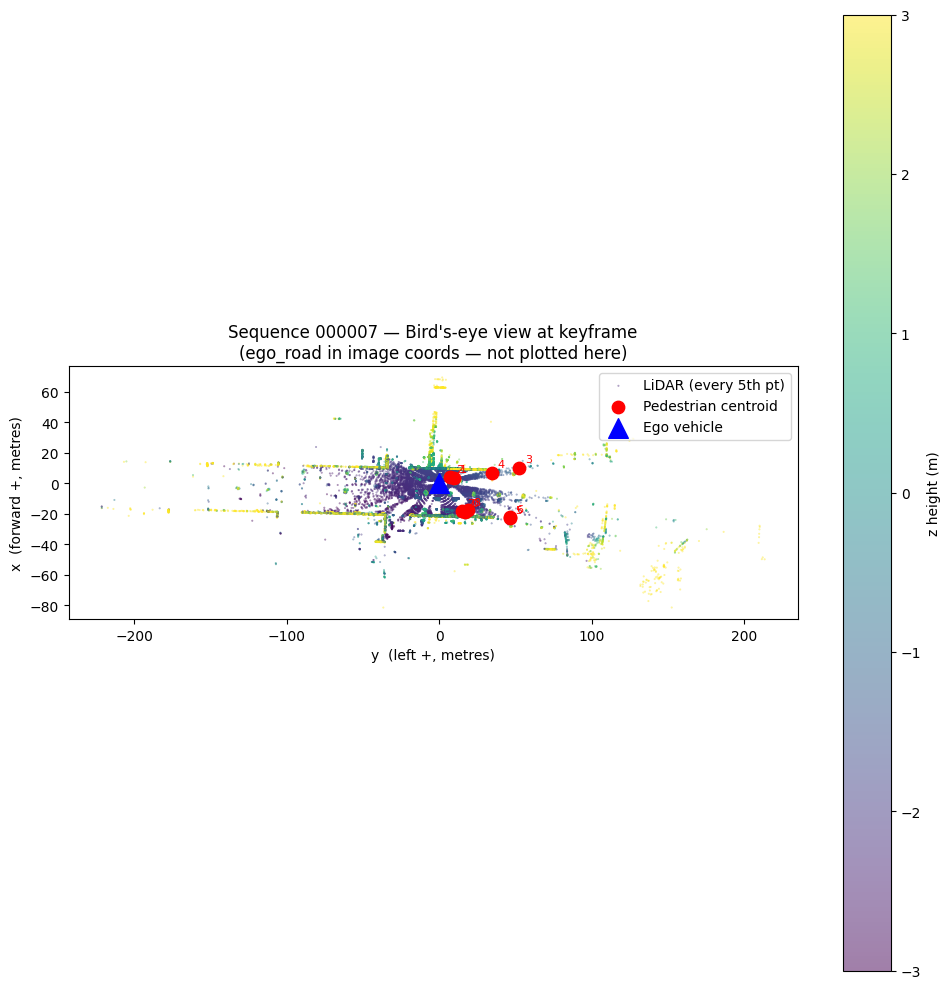

Saved: seq000007_bev.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

# --- LiDAR points (bird's eye: x forward, y left) ---
# Thin out for plotting: take every 5th point
pts_sub = pts[::5]
ax.scatter(
    pts_sub[:, 1], pts_sub[:, 0],   # flip to standard map orientation (y→right)
    s=0.2, c=pts_sub[:, 2], cmap="viridis",
    vmin=-3, vmax=3, alpha=0.5, label="LiDAR (every 5th pt)",
)

# --- Pedestrian centroids ---
ax.scatter(
    ped_centroids[:, 1], ped_centroids[:, 0],
    s=80, c="red", zorder=5, label="Pedestrian centroid",
)

# Label each pedestrian
for i, (cx, cy, cz) in enumerate(ped_centroids):
    ax.annotate(str(i), (cy, cx), textcoords="offset points", xytext=(4, 4),
                fontsize=8, color="red")

# --- Ego vehicle marker ---
ax.scatter([0], [0], s=200, c="blue", marker="^", zorder=6, label="Ego vehicle")

ax.set_xlabel("y  (left +, metres)")
ax.set_ylabel("x  (forward +, metres)")
ax.set_title(f"Sequence {SEQ_ID} — Bird's-eye view at keyframe\n"
             f"(ego_road in image coords — not plotted here)")
ax.set_aspect("equal")
ax.legend(loc="upper right")
plt.colorbar(ax.collections[0], ax=ax, label="z height (m)")
plt.tight_layout()
plt.savefig("seq000007_bev.png", dpi=150)
plt.show()
print("Saved: seq000007_bev.png")

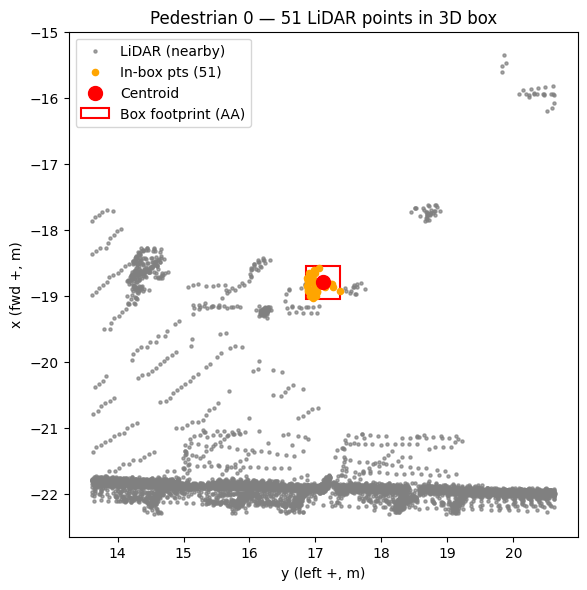

Saved: seq000007_ped0_box.png


In [14]:
# Zoom in on the first pedestrian's box to visually confirm LiDAR hit
idx, n_pts, mask = ped_box_results[0]
cx, cy, cz = ped_centroids[idx]
l = peds_3d[idx]["properties"]["size_3d_length"]
w = peds_3d[idx]["properties"]["size_3d_width"]

fig, ax = plt.subplots(figsize=(6, 6))

margin = 3.0
nearby = (
    (np.abs(pts[:, 0] - cx) < margin + l) &
    (np.abs(pts[:, 1] - cy) < margin + w)
)
pts_near = pts[nearby]

ax.scatter(pts_near[:, 1], pts_near[:, 0], s=5, c="gray", alpha=0.7, label="LiDAR (nearby)")
ax.scatter(pts[mask, 1], pts[mask, 0], s=20, c="orange", zorder=4, label=f"In-box pts ({n_pts})")
ax.scatter([cy], [cx], s=100, c="red", zorder=5, label="Centroid")

# Draw axis-aligned box footprint for reference
rect = patches.Rectangle(
    (cy - w / 2, cx - l / 2), w, l,
    linewidth=1.5, edgecolor="red", facecolor="none", label="Box footprint (AA)"
)
ax.add_patch(rect)

ax.set_xlabel("y (left +, m)")
ax.set_ylabel("x (fwd +, m)")
ax.set_title(f"Pedestrian 0 — {n_pts} LiDAR points in 3D box")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.savefig("seq000007_ped0_box.png", dpi=150)
plt.show()
print("Saved: seq000007_ped0_box.png")

---
## Summary

| Check | Result |
|-------|--------|
| Pedestrian fields in `object_detection.json` | ✓ `location_3d` in **ego/sensor frame** (metres); quaternion + size fields present |
| Nearest LiDAR to keyframe | ✓ gap = **37.4 ms** (≤ 55 ms limit) — file `...T15:24:35.666774Z.npy` |
| LiDAR points in pedestrian 3D boxes | ✓ points confirmed inside boxes — frames match |
| `ego_road.json` coordinate frame | ⚠ **image (pixel) coordinates** — NOT ego/3D frame |
| Bird's-eye plot | ✓ LiDAR + ped centroids plotted; road polygon omitted (image-space coords) |

### Action items before pipeline
- **ego_road:** Either project the road polygon from image space into ego/3D space using the camera model in `calibration.json` (Kannala fisheye), or project pedestrian `location_3d` into image space for road-overlap checks. Projection via `calibration.json → FC → extrinsics + intrinsics + distortion` is required.
- **ego_motion compensation:** For sequences where the LiDAR gap approaches 55 ms, compensate by transforming LiDAR points using the pose delta from `ego_motion.json`. Not critical for gap=37.4 ms but needed as a general pipeline step.